2026-05-27 22:36:22.635856: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


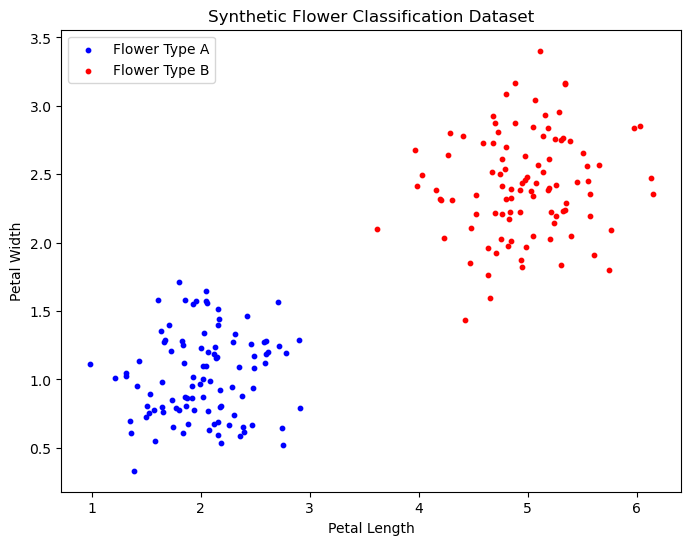

In [1]:
# Implementation using TensorFlow
# Binary Classification Example: Flower Type Classification

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# Generate data for Flower Type A
num_samples = 100

flower_A_petal_length = np.random.normal(2.0, 0.4, num_samples)
flower_A_petal_width = np.random.normal(1.0, 0.3, num_samples)
flower_A = np.column_stack((flower_A_petal_length, flower_A_petal_width))
labels_A = np.zeros(num_samples)

# Generate data for Flower Type B
flower_B_petal_length = np.random.normal(5.0, 0.5, num_samples)
flower_B_petal_width = np.random.normal(2.5, 0.4, num_samples)
flower_B = np.column_stack((flower_B_petal_length, flower_B_petal_width))
labels_B = np.ones(num_samples)

# Combine the two flower datasets
data = np.vstack((flower_A, flower_B)).astype(np.float32)
labels = np.hstack((labels_A, labels_B)).astype(np.float32).reshape(-1, 1)

# Shuffle the dataset
shuffle_index = np.random.permutation(len(data))
data = data[shuffle_index]
labels = labels[shuffle_index]

# Prepare TensorFlow training data
x_train = data
y_train = labels

# Visualize the original dataset
plt.figure(figsize=(8, 6))

plt.scatter(
    flower_A_petal_length,
    flower_A_petal_width,
    color="blue",
    s=10,
    label="Flower Type A"
)

plt.scatter(
    flower_B_petal_length,
    flower_B_petal_width,
    color="red",
    s=10,
    label="Flower Type B"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Synthetic Flower Classification Dataset")
plt.legend()
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000, Loss: 0.6299, Accuracy: 50.00%
Epoch 101/1000, Loss: 0.3231, Accuracy: 97.50%
Epoch 201/1000, Loss: 0.1488, Accuracy: 100.00%
Epoch 301/1000, Loss: 0.0804, Accuracy: 100.00%
Epoch 401/1000, Loss: 0.0509, Accuracy: 100.00%
Epoch 501/1000, Loss: 0.0359, Accuracy: 100.00%
Epoch 601/1000, Loss: 0.0272, Accuracy: 100.00%
Epoch 701/1000, Loss: 0.0217, Accuracy: 100.00%
Epoch 801/1000, Loss: 0.0180, Accuracy: 100.00%
Epoch 901/1000, Loss: 0.0153, Accuracy: 100.00%


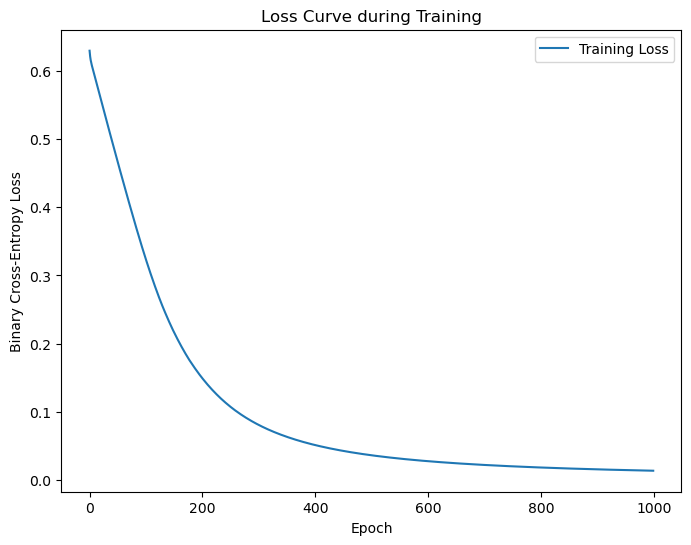

In [3]:
# Define the TensorFlow ANN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),                  # Input layer: 2 features
    tf.keras.layers.Dense(6, activation="relu"), # Hidden layer: 6 neurons with ReLU
    tf.keras.layers.Dense(1, activation="sigmoid") # Output layer for binary classification
])

model.summary()

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

# Train the model
epochs = 1000

history = model.fit(
    x_train,
    y_train,
    epochs=epochs,
    verbose=0
)

# Print loss every 100 epochs
for epoch in range(0, epochs, 100):
    loss_value = history.history["loss"][epoch]
    accuracy_value = history.history["accuracy"][epoch]
    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {loss_value:.4f}, "
        f"Accuracy: {accuracy_value * 100:.2f}%"
    )

# Plot the loss curve
plt.figure(figsize=(8, 6))
plt.plot(
    np.arange(epochs),
    np.array(history.history["loss"], dtype=np.float32),
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve during Training")
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


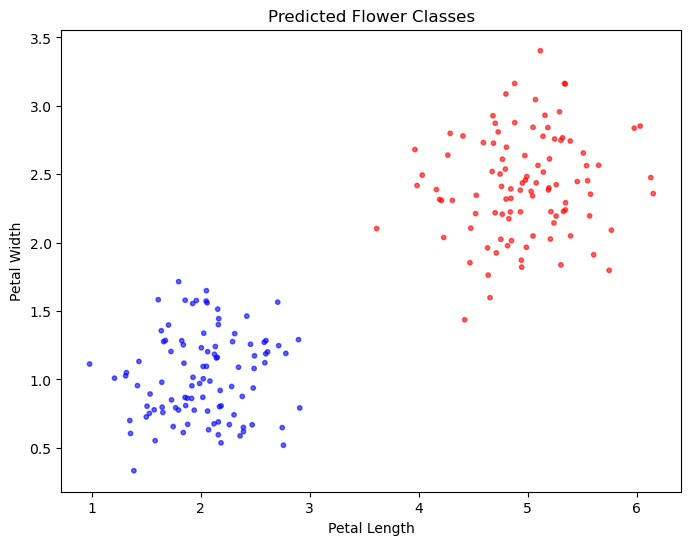

Final Accuracy: 100.00%


In [4]:
# Generate model predictions
predictions = model.predict(x_train)
predicted_labels = (predictions >= 0.5).astype(np.float32)

# Visualize classification results
plt.figure(figsize=(8, 6))

plt.scatter(
    data[:, 0],
    data[:, 1],
    c=predicted_labels.reshape(-1),
    cmap="bwr",
    s=10,
    alpha=0.6
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Predicted Flower Classes")
plt.show()

# Calculate final classification accuracy
final_accuracy = np.mean(predicted_labels == y_train)

print(f"Final Accuracy: {final_accuracy * 100:.2f}%")